# Month 1: Maxwell Equations, Fourier Integrals, Complex Numbers

**Computational Microplastic Optical Sensing** -- research chain:

`Maxwell equations -> complex refractive index -> absorption/scattering -> `
`laser/THz pulse -> Fourier transform -> detector model -> ADC sampling -> `
`statistical uncertainty -> parameter estimation`

This notebook builds the month-1 foundation: everything later months (dispersion,
scattering, detector noise, inversion) is built on top of.

## §1 Complex Refractive Index

$$\tilde{n}(\omega) = n(\omega) + i\kappa(\omega)$$

For a simple nonmagnetic optical model, Maxwell's equations relate this directly
to the relative permittivity:

$$\varepsilon_r = \tilde{n}^2$$

- $n$ (real part) sets the phase velocity $v_p = c/n$ -- **dispersion**
- $\kappa$ (imaginary part) sets the exponential decay -- **absorption**


In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))

from dgs.microplastic import physics as mp
import numpy as np
import matplotlib.pyplot as plt

n_water, kappa_water = 1.33, 0.00001   # visible-light water-like medium
n_tilde = mp.complex_index(n_water, kappa_water)
eps_r = mp.permittivity(n_tilde)

print(f"n~ = {n_tilde}")
print(f"eps_r = n~^2 = {eps_r}")
print(f"Re(eps_r) = {eps_r.real:.6f}  (sets dispersion)")
print(f"Im(eps_r) = {eps_r.imag:.3e}  (sets absorption, > 0 for a lossy medium)")


n~ = (1.33+1e-05j)
eps_r = n~^2 = (1.7688999999000001+2.6600000000000003e-05j)
Re(eps_r) = 1.768900  (sets dispersion)
Im(eps_r) = 2.660e-05  (sets absorption, > 0 for a lossy medium)


## §2 Propagation Through a Slab

$$k\tilde{} = \tilde{n}\,\omega/c \qquad E(z,\omega) = E(0,\omega)\,e^{i\tilde{k}z}$$

The imaginary part of $\tilde{k}$ makes $|E(z)|^2$ decay exponentially --
**Beer-Lambert's law falls straight out of the complex exponential**, it is not a
separate postulate:

$$\alpha = \frac{2\omega\kappa}{c} \qquad |E(z)|^2 = |E(0)|^2 e^{-\alpha z}$$


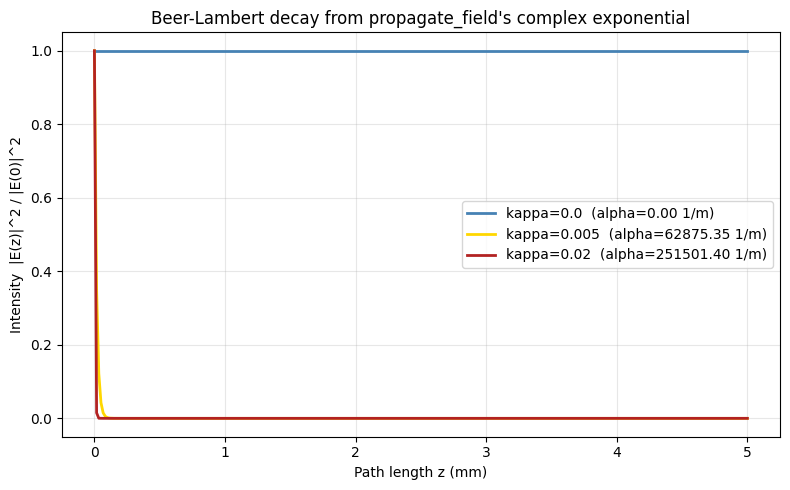

max |propagate_field intensity - beer_lambert_transmittance| = 4.24e-22


In [2]:
omega = 2*np.pi*3e14   # ~1000 nm optical carrier
kappa_vals = [0.0, 0.005, 0.02]   # increasing absorption
z = np.linspace(0, 5e-3, 300)     # 0-5 mm path length

fig, ax = plt.subplots(figsize=(8,5))
for kappa, col in zip(kappa_vals, ["steelblue","gold","firebrick"]):
    n_t = mp.complex_index(n_water, kappa)
    k_t = mp.wave_number(n_t, omega)
    E = mp.propagate_field(1.0, k_t, z)
    alpha = mp.absorption_coefficient(omega, kappa)
    ax.plot(z*1e3, np.abs(E)**2, lw=2, color=col,
            label=f"kappa={kappa}  (alpha={alpha:.2f} 1/m)")

ax.set_xlabel("Path length z (mm)")
ax.set_ylabel("Intensity  |E(z)|^2 / |E(0)|^2")
ax.set_title("Beer-Lambert decay from propagate_field's complex exponential")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("beer_lambert_decay.png", dpi=90)
plt.show()

# cross-check: propagate_field's decay matches beer_lambert_transmittance directly
kappa = 0.02
alpha = mp.absorption_coefficient(omega, kappa)
k_t = mp.wave_number(mp.complex_index(n_water, kappa), omega)
E = mp.propagate_field(1.0, k_t, z)
resid = np.max(np.abs(np.abs(E)**2 - mp.beer_lambert_transmittance(alpha, z)))
print(f"max |propagate_field intensity - beer_lambert_transmittance| = {resid:.2e}")


## §3 Time-Averaged Poynting Vector

$$\langle S \rangle = \tfrac{1}{2} n\,\varepsilon_0 c\,E_0^2$$

Power through an area $A$: $P=\int_A S\,dA$. A denser medium (higher $n$) carries
more power for the same field amplitude $E_0$ -- useful later for normalizing
detector signal against the surrounding medium's index.


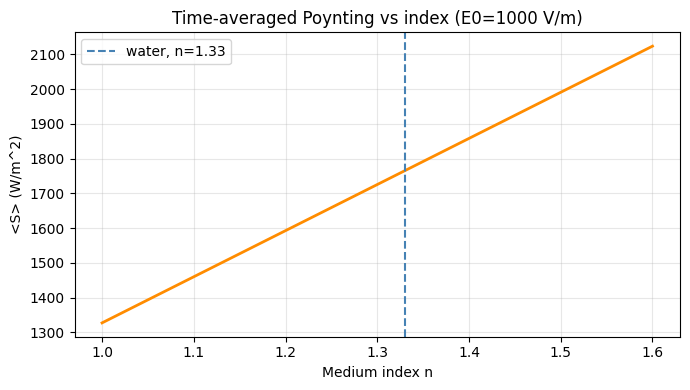

vacuum (n=1):   <S> = 1.327e+03 W/m^2
water (n=1.33): <S> = 1.765e+03 W/m^2


In [3]:
E0 = 1e3  # V/m
n_range = np.linspace(1.0, 1.6, 200)
S = mp.time_averaged_poynting(E0, n_range)

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(n_range, S, lw=2, color="darkorange")
ax.axvline(1.33, color="steelblue", ls="--", label="water, n=1.33")
ax.set_xlabel("Medium index n")
ax.set_ylabel("<S> (W/m^2)")
ax.set_title(f"Time-averaged Poynting vs index (E0={E0:.0f} V/m)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("poynting_vs_index.png", dpi=90)
plt.show()

print(f"vacuum (n=1):   <S> = {mp.time_averaged_poynting(E0, 1.0):.3e} W/m^2")
print(f"water (n=1.33): <S> = {mp.time_averaged_poynting(E0, 1.33):.3e} W/m^2")


## §4 Fourier Transform Pair: Numeric vs Analytic

A Gaussian pulse transforms to a Gaussian spectrum -- the time-bandwidth product
this whole repo's dispersion kernel exploits:

$$E(t)=e^{-t^2/2\tau^2} \;\longleftrightarrow\; E(\omega)=\tau\sqrt{2\pi}\,e^{-\tau^2\omega^2/2}$$

We validate the FFT-based numeric transform against this closed form.


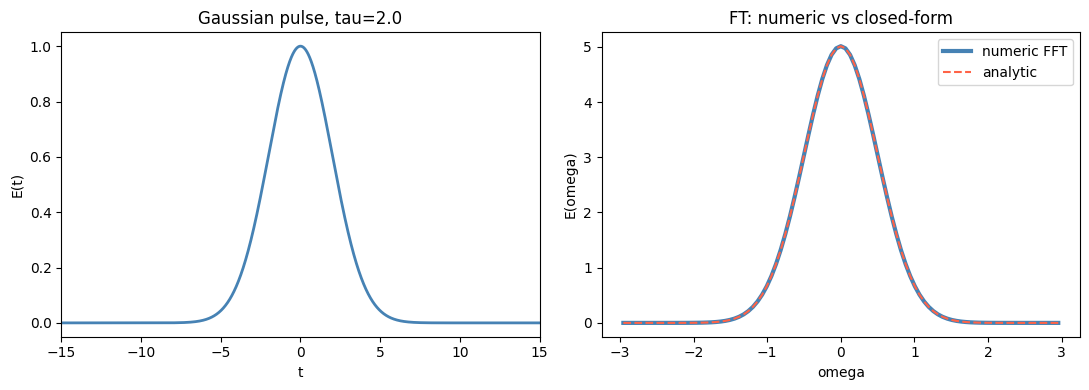

max relative error (numeric vs analytic FT): 7.61e-13


In [4]:
t = np.linspace(-50, 50, 20000)
tau = 2.0
Et = mp.gaussian_pulse(t, tau=tau, omega0=0.0)
omega_ax, Ef_num = mp.fourier_transform(t, Et)
Ef_analytic = mp.gaussian_pulse_ft_analytic(omega_ax, tau=tau, omega0=0.0)

fig, axes = plt.subplots(1, 2, figsize=(11,4))
axes[0].plot(t, Et.real, lw=2, color="steelblue")
axes[0].set_xlim(-15, 15)
axes[0].set_xlabel("t"); axes[0].set_ylabel("E(t)")
axes[0].set_title(f"Gaussian pulse, tau={tau}")

mask = np.abs(omega_ax) < 3
axes[1].plot(omega_ax[mask], Ef_num.real[mask], lw=3, color="steelblue", label="numeric FFT")
axes[1].plot(omega_ax[mask], Ef_analytic.real[mask], lw=1.5, ls="--", color="tomato", label="analytic")
axes[1].set_xlabel("omega"); axes[1].set_ylabel("E(omega)")
axes[1].set_title("FT: numeric vs closed-form")
axes[1].legend()
plt.tight_layout()
plt.savefig("gaussian_ft_validation.png", dpi=90)
plt.show()

core = np.abs(omega_ax) < 3/tau
rel_err = np.max(np.abs(Ef_num[core]-Ef_analytic[core])) / np.max(np.abs(Ef_analytic[core]))
print(f"max relative error (numeric vs analytic FT): {rel_err:.2e}")


## §5 Parseval's Theorem: Energy Conservation

$$\int |E(t)|^2\,dt \;=\; \frac{1}{2\pi}\int |E(\omega)|^2\,d\omega$$

Every later transfer-function step (dispersive slab, detector filter) preserves
this identity if it's implemented correctly -- a cheap, powerful self-check.


In [5]:
t_energy, f_energy, rel_err = mp.parseval_check(t, Et, omega_ax, Ef_num)
print(f"time-domain energy:      {t_energy:.6f}")
print(f"frequency-domain energy: {f_energy:.6f}")
print(f"relative error:          {rel_err:.2e}")


time-domain energy:      3.544908
frequency-domain energy: 3.544908
relative error:          5.56e-14


## §6 Round-Trip: E(t) -> E(omega) -> E(t)

Forward and inverse transforms must be exact inverses of each other (up to
floating-point precision) before we trust them on a dispersive transfer
function.


max |E_reconstructed - E_original| = 5.58e-14


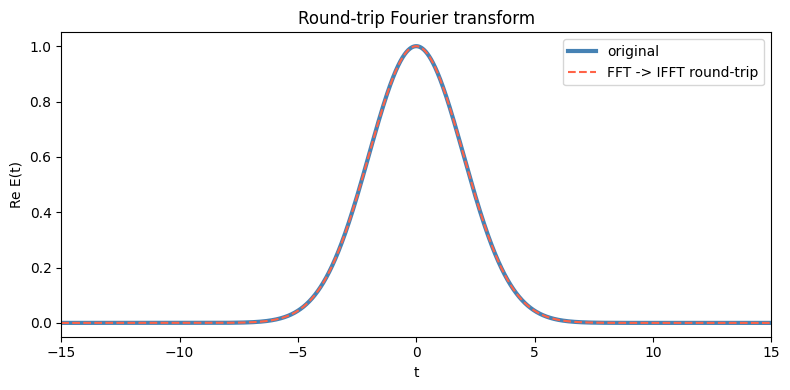

In [6]:
t2, Et_back = mp.inverse_fourier_transform(omega_ax, Ef_num, t0=t[0])
resid = np.max(np.abs(Et_back - Et))
print(f"max |E_reconstructed - E_original| = {resid:.2e}")

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(t, Et.real, lw=3, color="steelblue", label="original")
ax.plot(t2, Et_back.real, lw=1.5, ls="--", color="tomato", label="FFT -> IFFT round-trip")
ax.set_xlim(-15, 15)
ax.set_xlabel("t"); ax.set_ylabel("Re E(t)")
ax.legend()
ax.set_title("Round-trip Fourier transform")
plt.tight_layout()
plt.savefig("fft_roundtrip.png", dpi=90)
plt.show()


## §7 Photon Counting

$$\text{rate} = \frac{\text{photon count}}{\text{duration}}$$

Trivial, but it is the bridge from continuous field energy to discrete detector
counts -- month 5's shot-noise budget starts here.


In [7]:
print(f"1e9 photons over 10 s  -> {mp.photon_rate(1e9, 10):.3e} photons/s")
print(f"1e6 photons over 1 ms  -> {mp.photon_rate(1e6, 1e-3):.3e} photons/s")


1e9 photons over 10 s  -> 1.000e+08 photons/s
1e6 photons over 1 ms  -> 1.000e+09 photons/s


## §8 Where This Goes Next

Month 1 validated the tools. Month 2 builds the physical models on top of them:

| Month | Topic |
|-------|-------|
| 2 | Complex refractive index, absorption, dispersion, material transfer functions |
| 3 | Gaussian/THz pulse propagation through dispersive media |
| 4 | Particle-scattering model, synthetic microplastic concentration experiments |
| 5 | Detector, noise, ADC resolution, sampling, FFT, uncertainty analysis |
| 6 | PyTorch inverse model: estimate material parameters from simulated spectra |
| 7 | Temperature dependence, statistical validation, PCA vs conventional estimators |
| 8 | Reproducibility, documentation, figures, cost model, research presentation |

**First model**: synthetic particles in a synthetic blood-like medium.
**Advanced model** (later): replace the simple scattering approximation with
Mie theory or experimentally validated optical-property models.
